In [19]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
from shapely.geometry import Polygon

In [37]:
taxi_data_processed = pd.read_parquet(
    "../data/taxi_data_processed.parquet"
)

#final_grid = pd.read_parquet(
#    "../data/final_grid.parquet"
#)

## Comparison of the different spatial entities

In [ ]:
print(taxi_data_processed['h3_7_index_pickup'].nunique())
print(taxi_data_processed['h3_index_pickup'].nunique())
print(taxi_data_processed['h3_9_index_pickup'].nunique())
print(taxi_data_processed['Pickup Census Tract'].nunique())
print(taxi_data_processed['Pickup Community Area'].nunique())

110
360
491
495
75


In [40]:
(
    taxi_data_processed[["Pickup Census Tract", "h3_9_index_pickup"]]
    .drop_duplicates()
    .groupby("h3_9_index_pickup")
    .size()
    .describe()
)

count    491.000000
mean       1.008147
std        0.089982
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
dtype: float64

The number of spatial units decreases from 495 census tracts to 491 H3-9 cells, 360 H3-8 cells and 110 H3-7 cells. Due to privacy protection, pickup coordinates are mapped to census tract centroids. Consequently, the H3 discretization does not provide additional spatial detail. Instead, it creates alternative aggregation levels that allow the study of spatial smoothing and aggregation effects.

In [43]:
spatial_units = {
    "community_area": "Pickup Community Area",
    "census_tract": "Pickup Census Tract",
    "h3_7": "h3_7_index_pickup",
    "h3_8": "h3_index_pickup",
    "h3_9": "h3_9_index_pickup"
}

## Demand Analysis

In [41]:
spatial_demand = (
    taxi_data_processed
    .groupby("h3_index_pickup")
    .size()
    .reset_index(name="trip_count")
)
#spatial_demand

In [42]:
top_demand = (
    spatial_demand
    .sort_values("trip_count", ascending=False)
    .head(20)
)

#top_demand

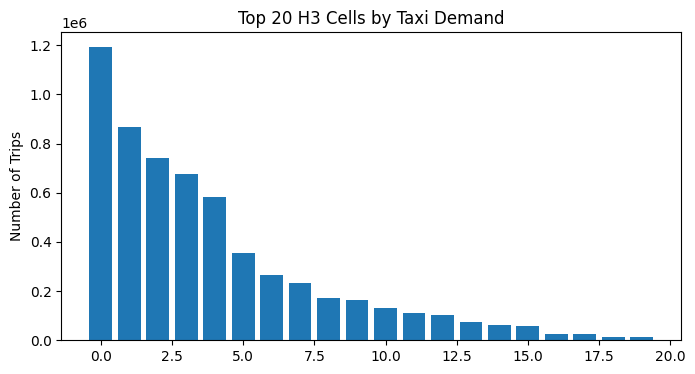

In [23]:
plt.figure(figsize=(8,4))

plt.bar(
    range(len(top_demand)),
    top_demand["trip_count"]
)

plt.title("Top 20 H3 Cells by Taxi Demand")
plt.ylabel("Number of Trips")

plt.show()

In [ ]:
def create_spatial_stats(df, group_col):

    return (
        df
        .groupby(group_col)
        .agg(
            trip_count=(group_col, "size"),
            avg_trip_length=("Trip Miles", "mean"),
            avg_price=("Trip Total", "mean"),
        )
        .reset_index()
    )


In [46]:
spatial_stats = {}

for name, col in spatial_units.items():
    spatial_stats[name] = create_spatial_stats(
        taxi_data_processed,
        col
    )

In [ ]:
gdfs = {}
levels = ["h3_7", "h3_8", "h3_9"]

for level in levels:

    h3_col = spatial_units[level]

    spatial_stats[level]["geometry"] = [
        Polygon(
            [(lng, lat) for lat, lng in h3.cell_to_boundary(h)]
        )
        for h in spatial_stats[level][h3_col]
    ]

    gdfs[level] = gpd.GeoDataFrame(
        spatial_stats[level],
        geometry="geometry",
        crs="EPSG:4326"
    )

    gdfs[level]["log_demand"] = np.log1p(gdfs[level]["trip_count"])

In [50]:
gdfs["h3_7"].total_bounds

array([-87.92947302,  41.64008885, -87.51550479,  42.03305375])

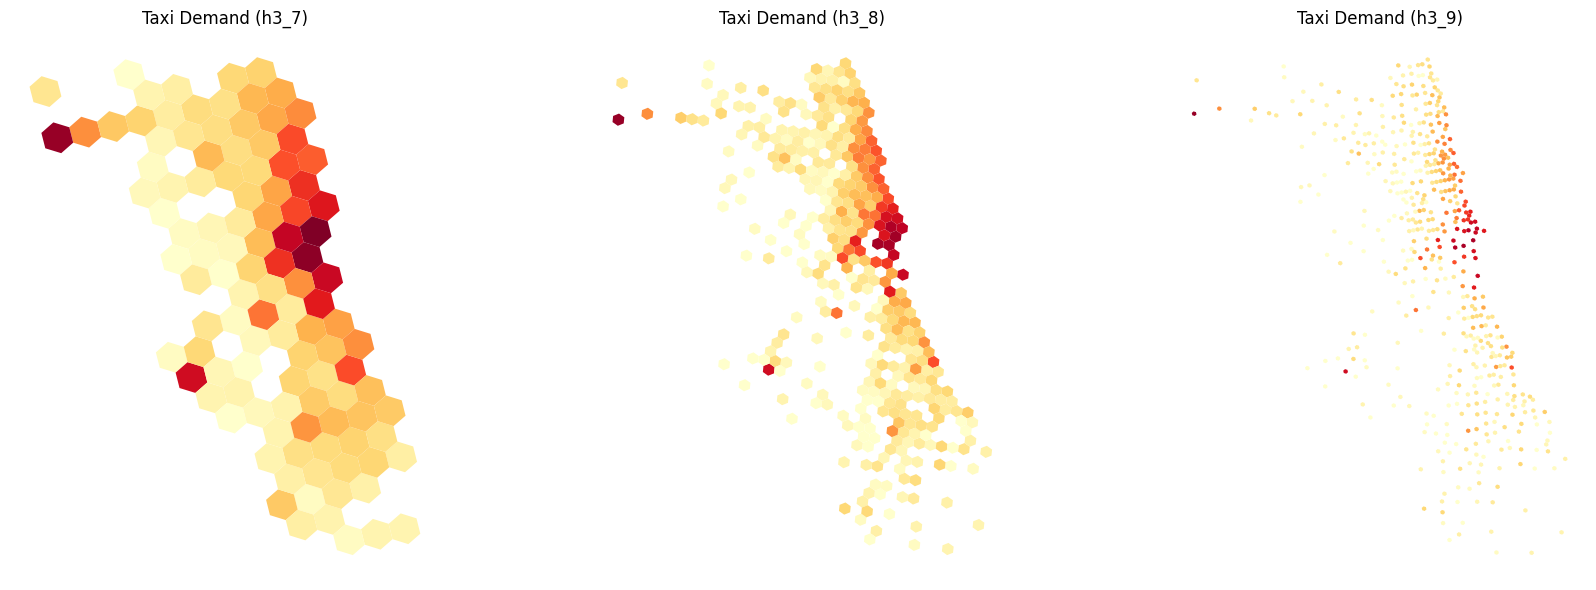

In [58]:
vmin = min(
    gdfs[level]["log_demand"].min()
    for level in levels
)
vmax = max(
    gdfs[level]["log_demand"].max()
    for level in levels
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)



for ax, level in zip(axes, levels):

    gdfs[level].plot(
        column="log_demand",
        cmap="YlOrRd",
        vmin=vmin,
        vmax=vmax,
        legend=False,
        ax=ax
    )

    ax.set_title(f"Taxi Demand ({level})")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [60]:
variables = ["log_demand", "avg_trip_length", "avg_price"]

for level in levels:
    for variable in variables:

        h3_col = spatial_units[level]

        m = folium.Map(
            location=[41.88, -87.63],
            zoom_start=11,
            tiles="CartoDB positron"
        )

        folium.Choropleth(
            geo_data=gdfs[level],
            data=gdfs[level],
            columns=[h3_col, variable],
            key_on=f"feature.properties.{h3_col}",
            fill_color="YlOrRd",
            fill_opacity=0.8,
            line_opacity=0.2,
            legend_name=variable
        ).add_to(m)

        m.save(
            f"../docs/maps/{level}_{variable}_map.html"
        )

In [ ]:
#todo: entscheiden ob wir für census tract und community area auch karten laden wollen
#falls ja, entsprechende daten einlesen und implementieren

